# Project 2

In the coding project below, answer any bolded questions on Canvas via the assigment named Programming Project 2 Quiz Questions.

In the following exercise, we will perform exploratory data analysis (EDA) to extract insights using Python. This assignment continues off of the previous assignment (Project 1). If you wish, you may copy and paste your previous code into this notebook.

In this assignment, we will be using PennGrader, a Python package built by a former TA for autograding Python notebooks. PennGrader was developed to provide students with instant feedback on their answer. You can submit your answer and know whether it's right or wrong instantly. We then record your most recent answer in our backend database. You will have 100 attempts per test case, which should be more than sufficient.

<b>NOTE：Please remember to remove the </b>

```python
raise notImplementedError
```
<b>after your implementation, otherwise the cell will not compile.</b>

## Getting Setup
Please run the below cells to get setup with the autograder. If you need to install packages, please uncomment and try the following lines; if they do not work, please try running them in the terminal without the `!` sign! (e.g. `pip install sklearn --user`

In [1]:
# %%capture
!pip install penngrader --user
!pip install seaborn --user

Let's try PennGrader out! Fill in the cell below with your PennID and then run the following cell to initialize the grader.

<font color='red'>Warning:</font> Please make sure you only have one copy of the student notebook in your directory in Codio upon submission. The autograder looks for the variable `STUDENT_ID` across all notebooks, so if there is a duplicate notebook, it will fail.

In [2]:
#PLEASE ENSURE YOUR STUDENT_ID IS ENTERED AS AN INT (NOT A STRING). IF NOT, THE AUTOGRADER WON'T KNOW WHO
#TO ASSIGN POINTS TO YOU IN OUR BACKEND

STUDENT_ID = 67110051                   # YOUR 8-DIGIT PENNID GOES HERE
STUDENT_NAME = "Ying-Pin Chen"     # YOUR FULL NAME GOES HERE

In [3]:
import penngrader.grader

grader = penngrader.grader.PennGrader(homework_id = 'ese5410_spr26_HW2', student_id = STUDENT_ID)

PennGrader initialized with Student ID: 67110051

Make sure this correct or we will not be able to store your grade


In [4]:
# Let's import the relevant Python packages here
# Feel free to import any other packages for this project

#Data Wrangling
import pandas as pd
import seaborn as sns
import numpy as np
#Plotting
import matplotlib.pyplot as plt

%matplotlib inline

## Part A

First, we return to the College dataset. This dataset contains the following variables from 777 different universities and colleges in the US:

| Column | Description |
|:-|:-|
|Private | Public/private indicator|
|Apps | Number of applications received|
|Accept | Number of applicants accepted|
|Enroll | Number of new students enrolled|
|Top10perc | New students from top 10\% of high school class|
|Top25perc | New students from top 25\% of high school class|
|F.Undergrad | Number of full-time undergraduates|
|P.Undergrad | Number of part-time undergraduates|
|Outstate | Out-of-state tuition|
|Room.Board | Room and board costs|
|Books | Estimated book costs|
|Personal | Estimated personal spending|
|PhD | Percent of faculty with Ph.D.’s|
|Terminal | Percent of faculty with terminal degree|
|S.F.Ratio | Student/faculty ratio|
|Perc.alumni | Percent of alumni who donate|
|Expend | Instructional expenditure per student|
|Grad.Rate | Graduation rate|

In [5]:
college = pd.read_csv('College.csv').copy()
college = college.rename(columns = {'Grad.Rate':'Grad_Rate',
                              'S.F.Ratio': 'S_F_Ratio',
                              'perc.alumni':'perc_alumni',
                              'Room.Board':'Room_Board',
                              'F.Undergrad':'F_Undergrad',
                              'P.Undergrad':'P_Undergrad'})

In [6]:
college.set_index('Names', inplace = True)
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
Names,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


1. Use the `seaborn` `pairplot()` function on the original dataframe with all universities to produce a scatterplot matrix of the ﬁrst ten columns of the data. Remember to use the `%matplotlib` inline command for plotting in Jupyter. Comment on your observations.

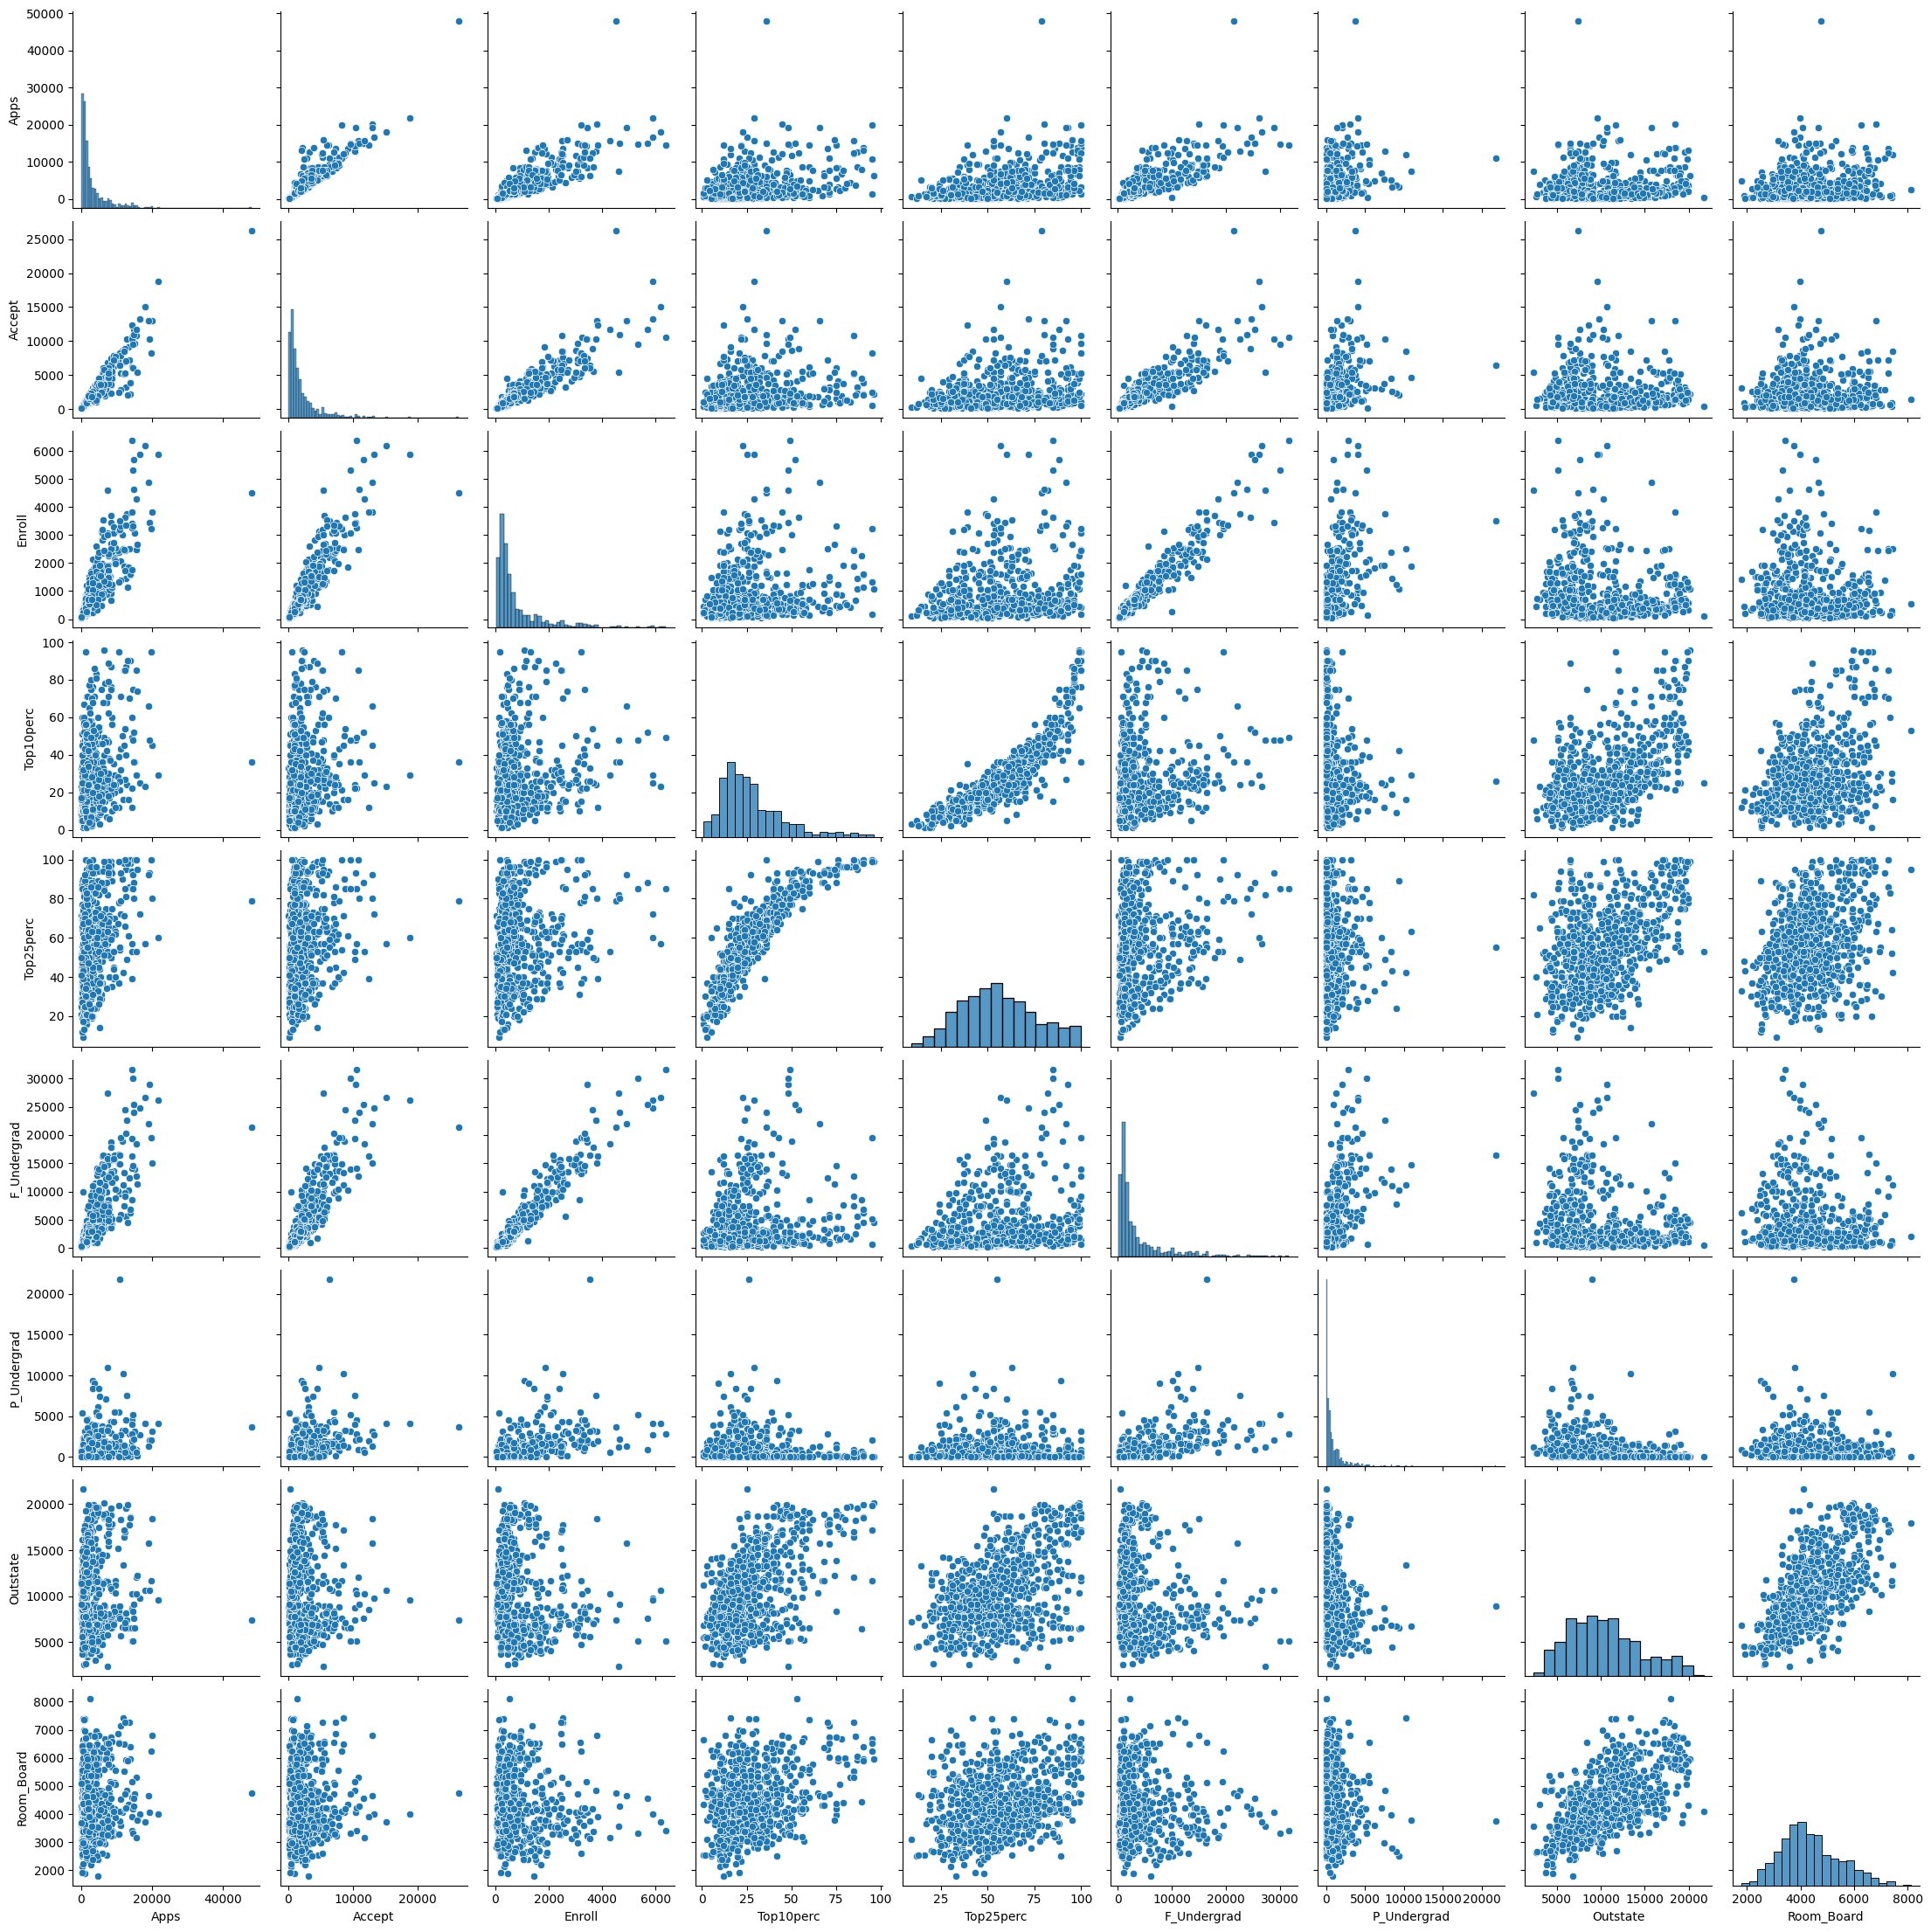

In [7]:
sns.pairplot(college.iloc[:, 0:10])
plt.show()

2. Use the `seaborn` `boxplot()` function on the original dataframe with all universities to produce side-by-side box plots of ‘Outstate’ versus ‘Private’. <b>Answer on Canvas: On average, are private universities more expensive than public universities?</b>

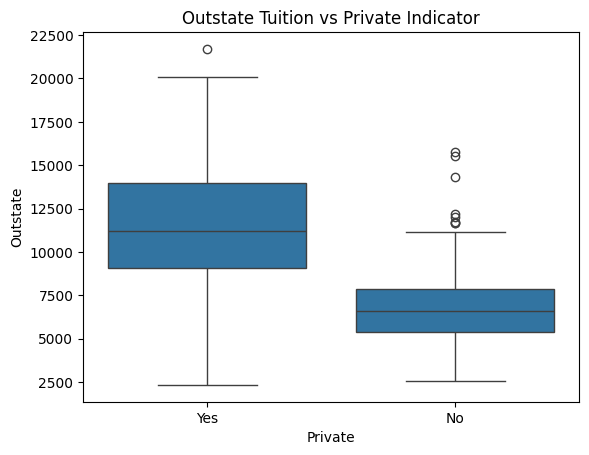

In [8]:
sns.boxplot(x='Private', y='Outstate', data=college)
plt.title('Outstate Tuition vs Private Indicator')
plt.show()

3. Create a new qualitative variable named `large_university` by binning the ‘Enroll’ column. We are going to divide universities into two groups based on whether the number of new students enrolled exceeds the average (mean) of all new students enrolled.  Hint: The variable `large_university` is an indicator variable (a Pandas series that represents a series of booleans, a list is also acceptable). In Python, this is called a "mask," which you can later manipulate to slice your data.

In [9]:
large_university = (college['Enroll'] > college['Enroll'].mean()).tolist()


In [10]:
grader.grade(test_case_id = 'large_university_bin_test', answer = large_university)

Correct! You earned 2.0/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


4. Create a dataframe called `large_universities` that only includes large universities.

In [11]:
large_universities = college[large_university]
large_universities.head()


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate
Names,,,,,,,,,,,,,,,,,,
Angelo State University,No,3540,2001,1016,24,54,4190,1512,5130,3592,500,2000,60,62,23.1,5,4010,34
Appalachian State University,No,7313,4664,1910,20,63,9940,1035,6806,2540,96,2000,83,96,18.3,14,5854,70
Arizona State University Main campus,No,12809,10308,3761,24,49,22593,7585,7434,4850,700,2100,88,93,18.9,5,4602,48
Arkansas Tech University,No,1734,1729,951,12,52,3602,939,3460,2650,450,1000,57,60,19.6,5,4739,48
Auburn University-Main Campus,No,7548,6791,3070,25,57,16262,1716,6300,3933,600,1908,85,91,16.7,18,6642,69


5. Use the `pandas` `describe(include = ‘all’)` function on large_universities to produce a numerical summary of each column. Within this dataframe, what is the $75^{th}$ percentile for the column ‘Enroll’? <b>Name this variable `enroll_answer` and enter your answer on Canvas.</b>

In [12]:
summary = large_universities.describe(include='all')
print(summary)

       Private          Apps        Accept       Enroll   Top10perc  \
count      218    218.000000    218.000000   218.000000  218.000000   
unique       2           NaN           NaN          NaN         NaN   
top         No           NaN           NaN          NaN         NaN   
freq       151           NaN           NaN          NaN         NaN   
mean       NaN   7233.376147   4734.110092  1897.229358   31.224771   
std        NaN   5069.744625   3186.820612  1124.121061   21.994342   
min        NaN   1256.000000   1068.000000   781.000000    3.000000   
25%        NaN   3943.250000   2686.500000  1058.000000   15.000000   
50%        NaN   6003.500000   3752.500000  1548.000000   25.000000   
75%        NaN   8756.500000   5692.250000  2408.000000   40.000000   
max        NaN  48094.000000  26330.000000  6392.000000   96.000000   

         Top25perc   F_Undergrad   P_Undergrad      Outstate   Room_Board  \
count   218.000000    218.000000    218.000000    218.000000   218.000

In [13]:
enroll_answer = float(large_universities['Enroll'].quantile(0.75))
print(f"75th percentile for Enroll: {enroll_answer}")

75th percentile for Enroll: 2408.0


In [14]:
grader.grade(test_case_id = 'enroll_test', answer = enroll_answer)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


6. Use the `seaborn` `boxplot()` function on the large_university variable to determine whether larger universities are more expensive. <b>Answer on Canvas: On average, are large universities more expensive than small universities?</b>

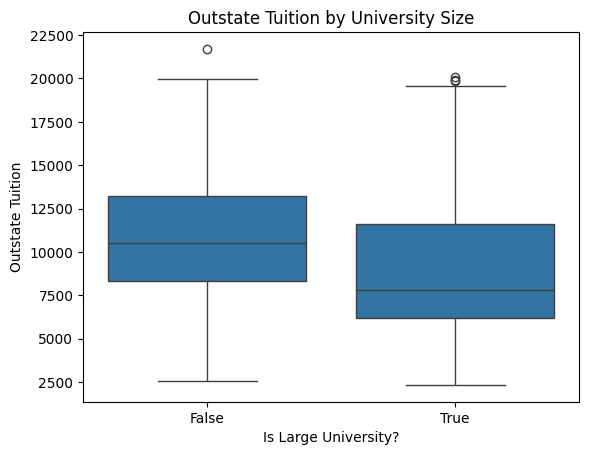

In [15]:
sns.boxplot(x=large_university, y=college['Outstate'])
plt.xlabel('Is Large University?')
plt.ylabel('Outstate Tuition')
plt.title('Outstate Tuition by University Size')
plt.show()

7. To further examine the relationship between the size of a university against its out-of-state tuition, plot a scatter plot. <b>Answer on Canvas: What type of relationship does this show (weak, medium, strong)?</b> Hint: Use the enrollment class size as a proxy for the size of a university.

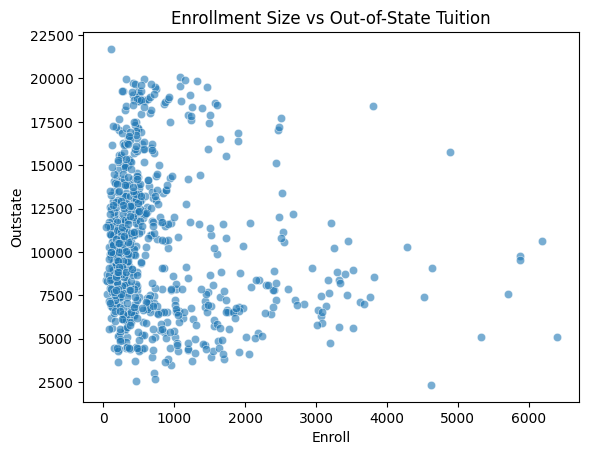

In [16]:
sns.scatterplot(x='Enroll', y='Outstate', data=college, alpha=0.6)
plt.title('Enrollment Size vs Out-of-State Tuition')
plt.show()

8. Use `matplotlib.pyplot.hist()` or `seaborn.distplot()` to produce some histograms with different numbers of bins for a few of the quantitative variables. You may ﬁnd the `matplotlib.pyplot.subplot()` function useful to plot multiple graphs under a single codeblock. In particular, create a histogram to examine the number of applications received with a bin size of 200. <b>Answer on Canvas: Are there more universities that receive 0 to 10,000 applications or 10,000 to 20,000 applications?</b>

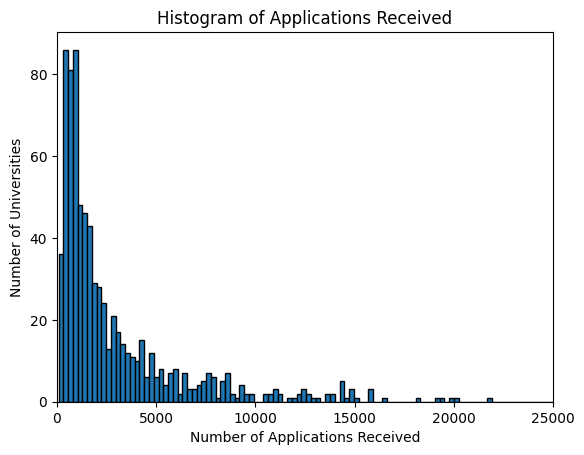

In [17]:
plt.hist(college['Apps'], bins=200, edgecolor='black')
plt.xlim(0, 25000)
plt.xlabel('Number of Applications Received')
plt.ylabel('Number of Universities')
plt.title('Histogram of Applications Received')
plt.show()

9. We are interested in the acceptance rate of these universities. To calculate the acceptance rate, we take the ‘Accept’ column and divide by the ‘Apps’ column. Add this column to a copied version of the original dataframe. Remember to copy the dataframe first before performing feature transformation, as we do not wish to alter or inadvertently create new columns in our original data. <b>Name your new column `acceptance_rate`. Answer on Canvas: Is there a positive or negative relationship between the university’s acceptance rate and the percentage of students in the university who graduated from the top 10% from high school?</b>

In [18]:
college_new = college.copy() #use copy() to assign to a new variable
acceptance_rate = college_new['Accept'] / college_new['Apps']
college_new['Acceptance_Rate'] = acceptance_rate
college_new.head()


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F_Undergrad,P_Undergrad,Outstate,Room_Board,Books,Personal,PhD,Terminal,S_F_Ratio,perc_alumni,Expend,Grad_Rate,Acceptance_Rate
Names,,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,0.742169
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,0.880146
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,0.768207
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,0.836930
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,0.756477


In [19]:
grader.grade(test_case_id = 'acceptance_rate_test', answer = acceptance_rate)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


*You may plot the university’s acceptance rate vs the percentage of students in the university who graduated from the top 10% from high school.*

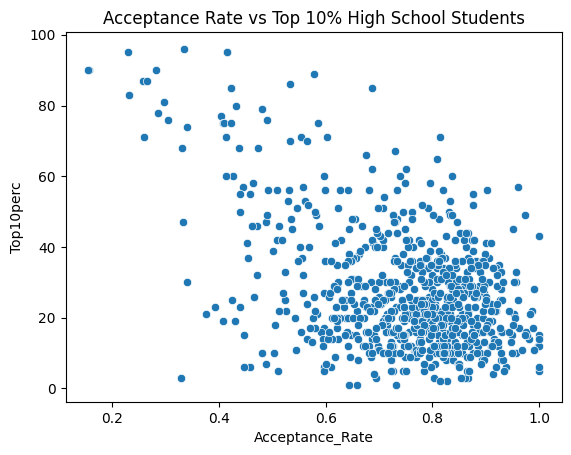

In [20]:
sns.scatterplot(x='Acceptance_Rate', y='Top10perc', data=college_new)
plt.title('Acceptance Rate vs Top 10% High School Students')
plt.show()

10. Continue exploring the data and provide a brief summary of what you discover.

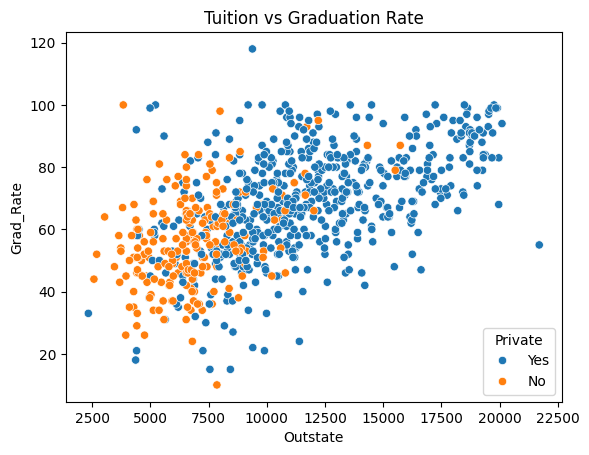

In [21]:
sns.scatterplot(x='Outstate', y='Grad_Rate', data=college, hue='Private')
plt.title('Tuition vs Graduation Rate')
plt.show()

## Part B

Next, let's turn to the California housing dataset, which contains the following variables from different districts in California based on the 1990 California census:

|Column |Description|
|:-|:-|
|MedInc | median income in block group |
|HouseAge | median house age in block group|
|AveRooms | average number of rooms per household|
|AveBedrms | average number of bedrooms per household|
|Population | block group population|
|AveOccup | average number of household members|
|Latitude | block group latitude|
|Longitude | block group longitude|
|MedHouseVal | Median house value in units of \$100,000|

1. To begin, load the California housing dataset. We can fetch this dataset by calling sklearn's API.

In [22]:
from sklearn.datasets import fetch_california_housing
california_dataset = fetch_california_housing()
california = pd.DataFrame(data = california_dataset.data, columns = california_dataset.feature_names)
california['MedHouseVal'] = pd.Series(california_dataset.target)
california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


2. Make pairwise scatterplots of some predictors (columns) in this dataset. Since this dataset includes many predictors, avoid using the `seaborn` `pairplot()` function with all the predictors to minimize run-time. Comment on your observations.

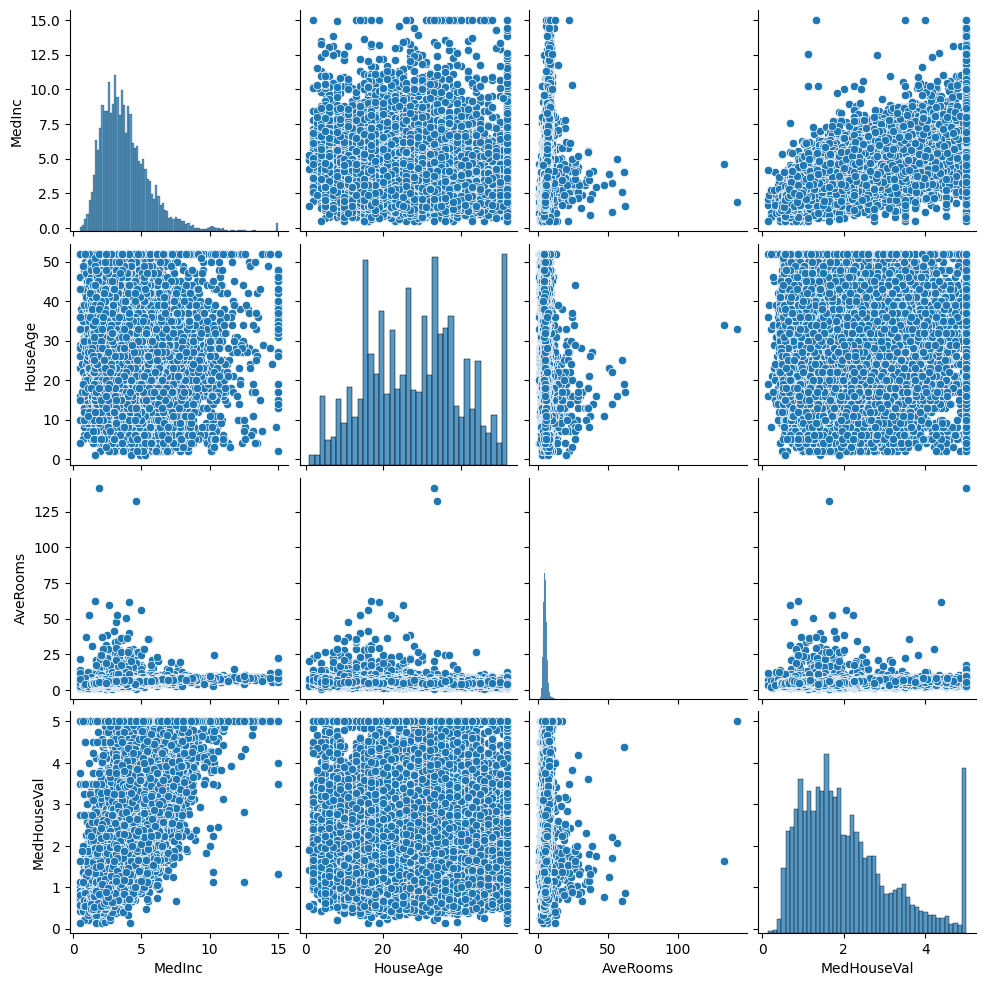

In [23]:
selected_cols = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']
sns.pairplot(california[selected_cols])
plt.show()

3. Are any of the predictors associated with Median House Value?  If so, explain the relationship. <b>Answer on Canvas: Which predictor has the highest correlation with 'MedHouseVal', besides MedHouseVal itself?<b>

In [24]:
correlations = california.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


4. Do any districts in the California housing dataset appear to have particularly high population counts, low median income levels, or high average household occupancy? Comment on the range of each predictor. <b>Answer on Canvas: Which district index has the highest population?
Which district index has the lowest median income?
Which district index has the highest average household occupancy?</b> Hint: Name the variables `highest_pop`, `lowest_med_inc`, and `highest_ave_occup` respectively. If there are multiple districts that share the same value, choose the first observation.

In [25]:
highest_pop = int(california['Population'].idxmax())
print(highest_pop)



15360


In [26]:
grader.grade(test_case_id = 'highest_pop_test', answer = highest_pop)



Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [27]:
lowest_med_inc = int(california['MedInc'].idxmin())
print(lowest_med_inc)

73


In [28]:
grader.grade(test_case_id = 'lowest_med_inc_test', answer = lowest_med_inc)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


In [29]:
highest_ave_occup = int(california['AveOccup'].idxmax())
print(highest_ave_occup)

19006


In [30]:
grader.grade(test_case_id = 'highest_ave_occup_test', answer = highest_ave_occup)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


5. Using the California housing dataset, count the number of districts located in the San Francisco Bay Area region, defined as districts with latitude between 37 and 38 degrees and longitude between -122 and -121 degrees.
Name this number as the variable `bay_area`. <b>Enter your answer on Canvas.</b>

In [31]:
bay_area_mask = (california['Latitude'] >= 37) & (california['Latitude'] <= 38) & \
                (california['Longitude'] >= -122) & (california['Longitude'] <= -121)

bay_area = int(bay_area_mask.sum())
print("There are %s districts located in the San Francisco Bay Area region." % (bay_area))

There are 1392 districts located in the San Francisco Bay Area region.


In [32]:
grader.grade(test_case_id = 'bay_area_test', answer = bay_area)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


6. Among the districts with median income (MedInc) greater than 5, compute the median average number of rooms (AveRooms). Name this value `med_rooms`. <b> Enter your answer on Canvas.</b>

In [33]:
med_rooms = float(california[california['MedInc'] > 5]['AveRooms'].median())
print("The median average number of rooms is %s, among the districts with median income greater than 5." % med_rooms)


The median average number of rooms is 6.50625, among the districts with median income greater than 5.


In [34]:
grader.grade(test_case_id = 'med_rooms_test', answer = med_rooms)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


7. Among the districts with median income (MedInc) greater than the overall median income, find the index of the district with the lowest median house value (MedHouseVal). Name this index `min_val` and **enter your answer on Canvas**. If multiple districts share the same minimum value, select the first such observation. After identifying this district, examine the values of its other predictors. How do these values compare with the overall ranges of those predictors in the dataset? Briefly comment on your observations.

In [35]:
overall_med_inc = california['MedInc'].median()
high_inc_districts = california[california['MedInc'] > overall_med_inc]
min_val = int(high_inc_districts['MedHouseVal'].idxmin())

print("The district with lowest median house value is #%s." % min_val)
california.iloc[[min_val]]
print(california.iloc[[min_val]])


The district with lowest median house value is #9188.
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
9188  4.1932      52.0  3.568889   1.186667       628.0  2.791111     34.24   

      Longitude  MedHouseVal  
9188    -117.86      0.14999  


In [36]:
grader.grade(test_case_id = 'min_val_test', answer = min_val)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


8. Compute the overall median of AveRooms in the California housing dataset. Then determine how many districts satisfy both of the following conditions:

*   AveRooms is greater than the overall median of AveRooms, and
*   MedHouseVal is greater than the overall median house value (MedHouseVal).

Name this count as the variable `num_districts` and <b>enter your answer on Canvas</b>.

In [37]:
overall_median_rooms = california['AveRooms'].median()
overall_median_house_val = california['MedHouseVal'].median()
condition = (california['AveRooms'] > overall_median_rooms) & \
            (california['MedHouseVal'] > overall_median_house_val)

num_districts = int(condition.sum())
print(f"Number of districts: {num_districts}")


Number of districts: 6120


In [38]:
grader.grade(test_case_id = 'num_districts_test', answer = num_districts)

Correct! You earned 2/2 points. You are a star!

Your submission has been successfully recorded in the gradebook.


*What other observations can you make from this dataset?*

## Submit

You're done! Please make sure you've run all the PennGrader cells and count up your score to be sure (there are 20 points in total) and then make sure to submit this on Codio.